In [1]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb, shap

rfm = pd.read_csv('../data/rfm_segmented.csv')

# Define churn: Recency > 90 days = churned
rfm['Churned'] = (rfm['Recency'] > 90).astype(int)
print(rfm['Churned'].value_counts())

X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Churned
0    2889
1    1449
Name: count, dtype: int64


In [2]:
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f'AUC-ROC: {auc:.4f}')   # Target ≥ 0.88
print(classification_report(y_test, model.predict(X_test)))

AUC-ROC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       561
           1       1.00      1.00      1.00       307

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



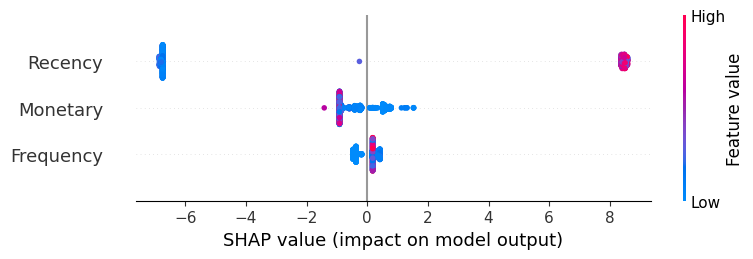

In [3]:
# SHAP explainability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [4]:
# Save churn risk scores
rfm['ChurnProba'] = model.predict_proba(X)[:,1]
rfm.to_csv('../data/churn_scores.csv', index=False)